# Student Dropout Prediction 



## 1. Install packages

In [ ]:
%pip install -q dtreeviz xgboost joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 3.2 MB/s eta 0:00:00


## 2. Imports and configuration

In [ ]:
import os
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    precision_score, recall_score, accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    PrecisionRecallDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# Avoid the repeated Arial font-manager messages.
logging.getLogger("matplotlib.font_manager").setLevel(logging.CRITICAL)
plt.rcParams["font.family"] = "DejaVu Sans"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")


Environment ready.


## 3. Load dataset

In [ ]:
possible_paths = [
    "/kaggle/input/higher-education-predictors-of-student-retention/dataset.csv",
    "/content/dataset.csv",
    "dataset.csv",
    "./data/dataset.csv"
]

csv_path = next((p for p in possible_paths if os.path.exists(p)), None)

# If the standard paths do not exist, search for a CSV containing Target.
if csv_path is None:
    for root, dirs, files in os.walk("."):
        dirs[:] = [d for d in dirs if not d.startswith(".")]
        for filename in files:
            if filename.lower().endswith(".csv"):
                candidate = os.path.join(root, filename)
                try:
                    test_df = pd.read_csv(candidate, nrows=5)
                    if "Target" in test_df.columns:
                        csv_path = candidate
                        break
                except Exception:
                    pass
        if csv_path is not None:
            break

if csv_path is None:
    raise FileNotFoundError(
        "dataset.csv was not found. Upload dataset.csv or place it at "
        "/content/dataset.csv."
    )

df = pd.read_csv(csv_path)

print("Dataset:", csv_path)
print("Shape:", df.shape)
display(df.head())


Dataset: /content/dataset.csv
Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 4. Data inspection

In [ ]:
df.info()

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nShape:", df.shape)
print("Size:", df.size)

display(df.describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

,Missing Values
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0



Shape: (4424, 35)
Size: 154840


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,6.886980,5.298964,1.00,1.00,8.000000,12.000000,18.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,9.899186,4.331792,1.00,6.00,10.000000,13.000000,17.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,2.531420,3.963707,1.00,1.00,1.000000,1.000000,17.000000
Nacionality,4424.0,1.254521,1.748447,1.00,1.00,1.000000,1.000000,21.000000
Mother's qualification,4424.0,12.322107,9.026251,1.00,2.00,13.000000,22.000000,29.000000
Father's qualification,4424.0,16.455244,11.044800,1.00,3.00,14.000000,27.000000,34.000000
Mother's occupation,4424.0,7.317812,3.997828,1.00,5.00,6.000000,10.000000,32.000000


## 5. Encode Target

In [ ]:
if "Target" not in df.columns:
    raise ValueError("The dataset must contain a 'Target' column.")

target_encoder = LabelEncoder()
df["Target"] = target_encoder.fit_transform(df["Target"])

print("Target mapping:")
for original, encoded in zip(
    target_encoder.classes_,
    target_encoder.transform(target_encoder.classes_)
):
    print(f"{original} -> {encoded}")

print("\nEncoded target counts:")
print(df["Target"].value_counts())


Target mapping:
Dropout -> 0
Enrolled -> 1
Graduate -> 2

Encoded target counts:
Target
2    2209
0    1421
1     794
Name: count, dtype: int64


## 6. Keep Graduate and Dropout; remove Enrolled

In [ ]:
# Find encoded values from the actual class names instead of assuming
# that a particular number always represents a particular class.

class_map = {
    str(label).strip().lower(): encoded
    for label, encoded in zip(
        target_encoder.classes_,
        target_encoder.transform(target_encoder.classes_)
    )
}

if "enrolled" in class_map:
    df = df[df["Target"] != class_map["enrolled"]].copy()

if "dropout" not in class_map or "graduate" not in class_map:
    raise ValueError(
        "Expected Target classes 'Dropout' and 'Graduate'. "
        f"Found: {list(target_encoder.classes_)}"
    )

dropout_code = class_map["dropout"]

df["Dropout"] = (df["Target"] == dropout_code).astype(int)

print("Final target:")
print(df["Dropout"].value_counts())

display(df.head())


Final target:
Dropout
0    2209
1    1421
Name: count, dtype: int64


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Dropout
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0.000000,0,10.8,1.4,1.74,0,1
1,1,6,1,11,1,1,1,1,3,4,...,6,6,6,13.666667,0,13.9,-0.3,0.79,2,0
2,1,1,5,5,1,1,1,22,27,10,...,6,0,0,0.000000,0,10.8,1.4,1.74,0,1
3,1,8,2,15,1,1,1,23,27,6,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,2,0
4,2,12,1,3,0,1,1,22,28,10,...,6,6,6,13.000000,0,13.9,-0.3,0.79,2,0


## 7. Prepare features

In [ ]:
excluded = {"Target", "Dropout"}
candidate_features = [c for c in df.columns if c not in excluded]

if len(candidate_features) < 34:
    raise ValueError(
        f"The notebook expects at least 34 feature columns. "
        f"Found {len(candidate_features)}."
    )

feature_names = candidate_features[:34]

X_df = df[feature_names].copy()
y = df["Dropout"].astype(int).copy()

non_numeric = X_df.select_dtypes(exclude=np.number).columns.tolist()

if non_numeric:
    raise ValueError(
        "These model features are non-numeric: "
        + ", ".join(non_numeric)
    )

print("Number of features:", len(feature_names))
print(feature_names)


Number of features: 34
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


## 8. Train/test split + scaling

In [ ]:
x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    X_df,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train_raw)
x_test = scaler.transform(x_test_raw)

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)


x_train: (2904, 34)
x_test : (726, 34)


## 9. Evaluation function

In [ ]:
def evaluate_model(model, name):
    pred = model.predict(x_test)

    print("=" * 65)
    print(name)
    print("=" * 65)
    print(f"Precision : {precision_score(y_test, pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_test, pred, zero_division=0):.4f}")
    print(f"Accuracy  : {accuracy_score(y_test, pred):.4f}")
    print(f"F1 Score  : {f1_score(y_test, pred, zero_division=0):.4f}")

    cm = confusion_matrix(y_test, pred)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        pred,
        target_names=["Non-Dropout", "Dropout"],
        zero_division=0
    ))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Dropout", "Dropout"]
    ).plot()

    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return pred


## 10. Gaussian Naive Bayes

Gaussian Naive Bayes
Precision : 0.8168
Recall    : 0.7852
Accuracy  : 0.8471
F1 Score  : 0.8007

Confusion Matrix:
[[392  50]
 [ 61 223]]

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.87      0.89      0.88       442
     Dropout       0.82      0.79      0.80       284

    accuracy                           0.85       726
   macro avg       0.84      0.84      0.84       726
weighted avg       0.85      0.85      0.85       726



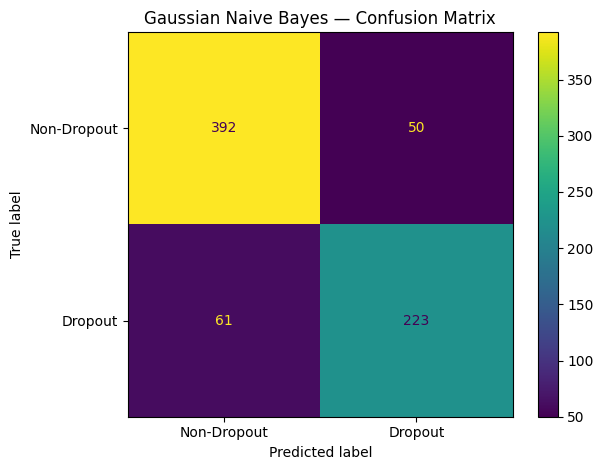

In [ ]:
model_nb = GaussianNB()
model_nb.fit(x_train, y_train)
y_pred_nb = evaluate_model(model_nb, "Gaussian Naive Bayes")


## 11. Logistic Regression

Logistic Regression
Precision : 0.9193
Recall    : 0.9225
Accuracy  : 0.9380
F1 Score  : 0.9209

Confusion Matrix:
[[419  23]
 [ 22 262]]

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.95      0.95      0.95       442
     Dropout       0.92      0.92      0.92       284

    accuracy                           0.94       726
   macro avg       0.93      0.94      0.93       726
weighted avg       0.94      0.94      0.94       726



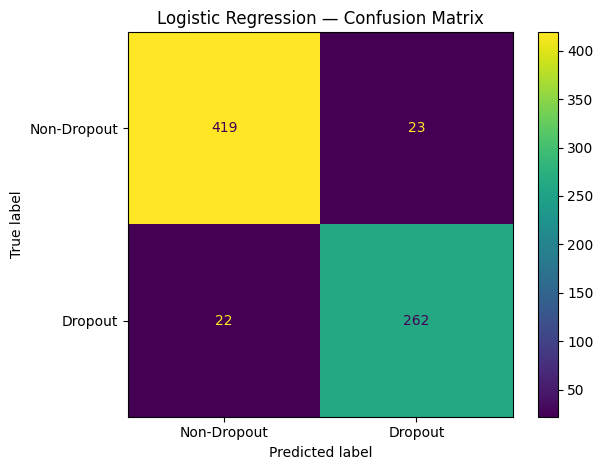

In [ ]:
model_lr = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)
model_lr.fit(x_train, y_train)
y_pred_lr = evaluate_model(model_lr, "Logistic Regression")


## 12. Random Forest

Random Forest
Precision : 0.9088
Recall    : 0.8768
Accuracy  : 0.9174
F1 Score  : 0.8925

Confusion Matrix:
[[417  25]
 [ 35 249]]

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.92      0.94      0.93       442
     Dropout       0.91      0.88      0.89       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726



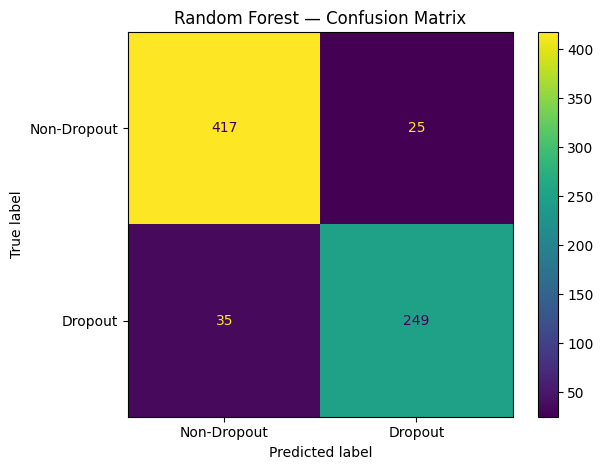

Number of trees: 100


In [ ]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_rf.fit(x_train, y_train)

y_pred_rf = evaluate_model(model_rf, "Random Forest")

print("Number of trees:", len(model_rf.estimators_))


## 13. Random Forest Feature Importance

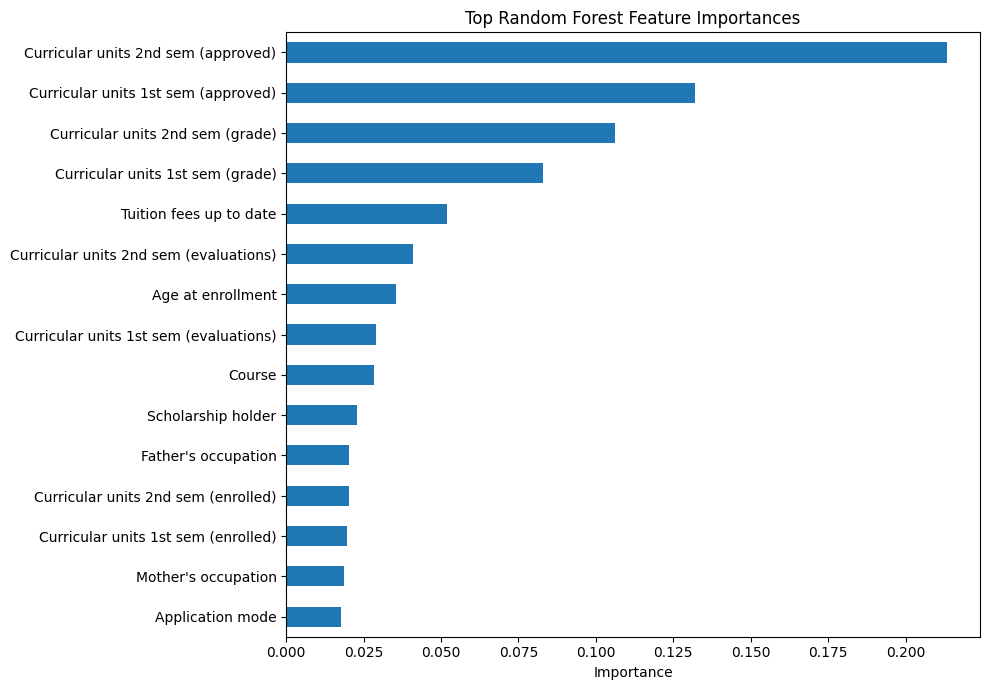

,Importance
Curricular units 2nd sem (approved),0.213354
Curricular units 1st sem (approved),0.131927
Curricular units 2nd sem (grade),0.106082
Curricular units 1st sem (grade),0.082957
Tuition fees up to date,0.051854
Curricular units 2nd sem (evaluations),0.041069
Age at enrollment,0.035359
Curricular units 1st sem (evaluations),0.029042
Course,0.028196
Scholarship holder,0.022884


In [ ]:
importance = pd.Series(
    model_rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(importance.head(15).to_frame("Importance"))


## 14. Random Forest Decision Tree Visualization — dtreeviz

**This cell is deliberately self-contained.**

If `model_rf` was accidentally deleted or the kernel was restarted, it retrains the Random Forest before accessing `.estimators_`.

If `x_train`, `y_train`, or `feature_names` are missing, it rebuilds them from `df`.


In [ ]:
# ============================================================
# SELF-CONTAINED RANDOM FOREST + DTREEVIZ CELL
# ============================================================

import logging
import matplotlib.pyplot as plt

# Suppress only the harmless Matplotlib font-manager warning.
logging.getLogger("matplotlib.font_manager").setLevel(logging.CRITICAL)
plt.rcParams["font.family"] = "DejaVu Sans"

# ------------------------------------------------------------
# A. Rebuild feature data if previous variables are missing
# ------------------------------------------------------------

if "df" not in globals():
    raise RuntimeError(
        "Dataset variable 'df' is missing. Run the dataset-loading cells first."
    )

if "feature_names" not in globals() or "y" not in globals():
    excluded = {"Target", "Dropout"}
    candidate_features = [c for c in df.columns if c not in excluded]

    if len(candidate_features) < 34:
        raise ValueError(
            f"Expected at least 34 feature columns, found {len(candidate_features)}."
        )

    feature_names = candidate_features[:34]
    X_df = df[feature_names].copy()
    y = df["Dropout"].astype(int).copy()

# ------------------------------------------------------------
# B. Rebuild train/test data if missing
# ------------------------------------------------------------

if any(name not in globals() for name in [
    "x_train", "x_test", "y_train", "y_test"
]):
    x_train_raw, x_test_raw, y_train, y_test = train_test_split(
        X_df,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train_raw)
    x_test = scaler.transform(x_test_raw)

# ------------------------------------------------------------
# C. IMPORTANT: guarantee model_rf exists
# ------------------------------------------------------------

if "model_rf" not in globals():
    print("model_rf not found — training Random Forest now...")

    model_rf = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model_rf.fit(x_train, y_train)

    print("Random Forest trained successfully.")

else:
    print("Existing model_rf found — using it.")

# ------------------------------------------------------------
# D. Guarantee at least one tree exists
# ------------------------------------------------------------

if not hasattr(model_rf, "estimators_") or len(model_rf.estimators_) == 0:
    raise RuntimeError(
        "Random Forest does not contain trained estimators. "
        "Please fit model_rf before visualization."
    )

# Use tree #50 when available; otherwise use the last available tree.
tree_index = min(50, len(model_rf.estimators_) - 1)

estimator = model_rf.estimators_[tree_index]

print(f"Visualizing Random Forest tree index: {tree_index}")

# ------------------------------------------------------------
# E. dtreeviz
# ------------------------------------------------------------

import dtreeviz

viz_model = dtreeviz.model(
    estimator,
    X_train=x_train,
    y_train=y_train,
    feature_names=list(feature_names),
    target_name="Student Dropout",
    class_names=["Non-Dropout", "Dropout"]
)

# Render SVG
v = viz_model.view()

# Save
output_file = "Dropout.svg"
v.save(output_file)

print("=" * 60)
print("SUCCESS")
print("=" * 60)
print(f"Tree index       : {tree_index}")
print(f"Number of trees  : {len(model_rf.estimators_)}")
print(f"Output file      : {output_file}")
print("dtreeviz rendered successfully.")
print("=" * 60)

v


Existing model_rf found — using it.
Visualizing Random Forest tree index: 50
SUCCESS
Tree index       : 50
Number of trees  : 100
Output file      : Dropout.svg
dtreeviz rendered successfully.


## 15. XGBoost

XGBoost
Precision : 0.9270
Recall    : 0.8944
Accuracy  : 0.9311
F1 Score  : 0.9104

Confusion Matrix:
[[422  20]
 [ 30 254]]

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.93      0.95      0.94       442
     Dropout       0.93      0.89      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.93       726
weighted avg       0.93      0.93      0.93       726



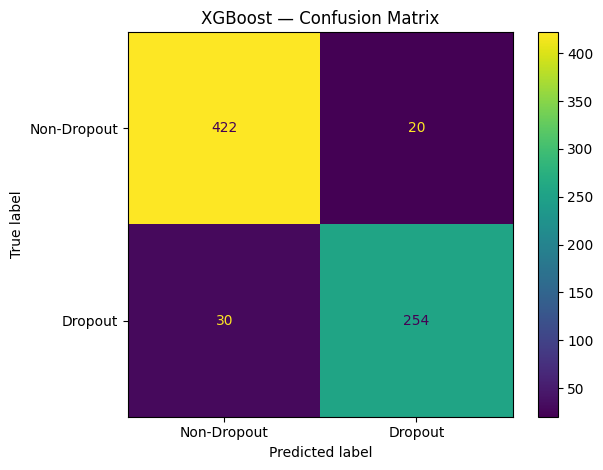

In [ ]:
model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_xgb.fit(x_train, y_train)
y_pred_xgb = evaluate_model(model_xgb, "XGBoost")


## 16. Support Vector Classifier

Support Vector Classifier
Precision : 0.9509
Recall    : 0.8873
Accuracy  : 0.9380
F1 Score  : 0.9180

Confusion Matrix:
[[429  13]
 [ 32 252]]

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.93      0.97      0.95       442
     Dropout       0.95      0.89      0.92       284

    accuracy                           0.94       726
   macro avg       0.94      0.93      0.93       726
weighted avg       0.94      0.94      0.94       726



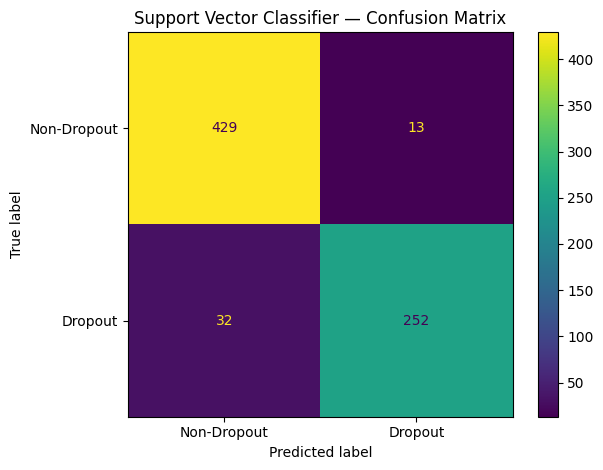

In [ ]:
model_svc = SVC(
    probability=True,
    random_state=RANDOM_STATE
)

model_svc.fit(x_train, y_train)
y_pred_svc = evaluate_model(model_svc, "Support Vector Classifier")


## 17. Multi-Layer Perceptron

Multi-Layer Perceptron
Precision : 0.9219
Recall    : 0.8310
Accuracy  : 0.9063
F1 Score  : 0.8741

Confusion Matrix:
[[422  20]
 [ 48 236]]

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.95      0.93       442
     Dropout       0.92      0.83      0.87       284

    accuracy                           0.91       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



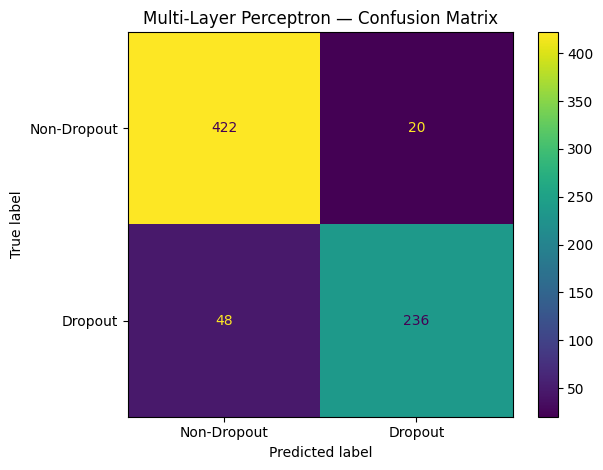

In [ ]:
model_mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    early_stopping=True,
    random_state=RANDOM_STATE
)

model_mlp.fit(x_train, y_train)
y_pred_mlp = evaluate_model(model_mlp, "Multi-Layer Perceptron")


## 18. Model comparison

In [ ]:
models = {
    "Gaussian NB": model_nb,
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "XGBoost": model_xgb,
    "SVC": model_svc,
    "MLP": model_mlp
}

results = []

for name, model in models.items():
    pred = model.predict(x_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0)
    })

comparison_df = pd.DataFrame(results)

display(comparison_df)


,Model,Accuracy,Precision,Recall,F1 Score
0,Gaussian NB,0.847107,0.816850,0.785211,0.800718
1,Logistic Regression,0.938017,0.919298,0.922535,0.920914
2,Random Forest,0.917355,0.908759,0.876761,0.892473
3,XGBoost,0.931129,0.927007,0.894366,0.910394
4,SVC,0.938017,0.950943,0.887324,0.918033
5,MLP,0.906336,0.921875,0.830986,0.874074


## 19. Precision-Recall Curve

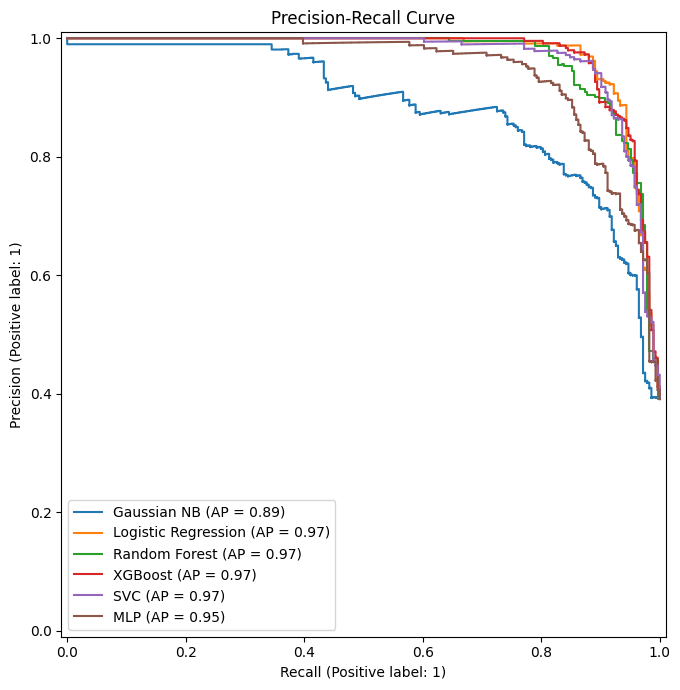

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(
        model,
        x_test,
        y_test,
        ax=ax,
        name=name
    )

ax.set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()


## 20. ROC Curve

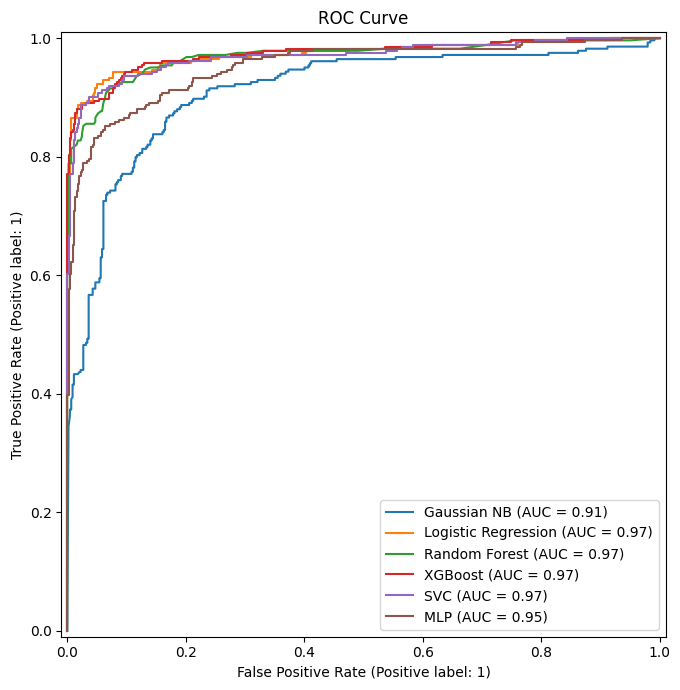

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        x_test,
        y_test,
        ax=ax,
        name=name
    )

ax.set_title("ROC Curve")
plt.tight_layout()
plt.show()


## 21. Example Student Dropout Prediction

In [ ]:
sample = x_test[0].reshape(1, -1)

prediction = model_rf.predict(sample)[0]
probability = model_rf.predict_proba(sample)[0, 1]

result = "Dropout" if prediction == 1 else "Non-Dropout"

print("Prediction:", result)
print(f"Dropout probability: {probability:.2%}")


Prediction: Non-Dropout
Dropout probability: 2.00%


## 22. Save project files

In [ ]:
import joblib

joblib.dump(model_rf, "student_dropout_random_forest.pkl")
joblib.dump(scaler, "student_dropout_scaler.pkl")

print("Saved successfully:")
print("1. Dropout.svg")
print("2. student_dropout_random_forest.pkl")
print("3. student_dropout_scaler.pkl")


Saved successfully:
1. Dropout.svg
2. student_dropout_random_forest.pkl
3. student_dropout_scaler.pkl


In [ ]:
# ============================================================
# FINAL CELL — AI HANDOFF / COMPLETE NOTEBOOK EXPORT
# ============================================================

import os
import glob
import json
import html
import base64
from datetime import datetime

print("Preparing AI-readable project report...")

# ------------------------------------------------------------
# 1. Find the currently saved notebook
# ------------------------------------------------------------

notebook_files = []

search_locations = [
    os.getcwd(),
    "/content",
    "/kaggle/working",
]

for location in search_locations:
    if os.path.exists(location):
        notebook_files.extend(
            glob.glob(os.path.join(location, "*.ipynb"))
        )

# Remove duplicates
notebook_files = list(dict.fromkeys(notebook_files))

# Try to identify the most recently modified notebook
notebook_path = None

if notebook_files:
    notebook_path = max(
        notebook_files,
        key=os.path.getmtime
    )

print("Notebook detected:", notebook_path)

# ------------------------------------------------------------
# 2. Create AI-readable report
# ------------------------------------------------------------

report_parts = []

report_parts.append("""
============================================================
STUDENT DROPOUT PREDICTION — AI PROJECT HANDOFF
============================================================

Purpose:
This file contains the executed notebook code and available
cell outputs so another AI can understand, debug, review,
and improve the project.

Generated:
""" + datetime.now().strftime("%Y-%m-%d %H:%M:%S") + """

============================================================
""")

# ------------------------------------------------------------
# 3. Read notebook cells
# ------------------------------------------------------------

if notebook_path is not None:

    try:
        import nbformat

        with open(notebook_path, "r", encoding="utf-8") as f:
            notebook = nbformat.read(f, as_version=4)

        for i, cell in enumerate(notebook.cells, start=1):

            report_parts.append(
                f"\n\n{'='*80}\n"
                f"CELL {i}\n"
                f"{'='*80}\n"
            )

            cell_type = cell.get("cell_type", "unknown")

            report_parts.append(
                f"CELL TYPE: {cell_type}\n\n"
            )

            # ------------------------------------------------
            # Markdown cell
            # ------------------------------------------------

            if cell_type == "markdown":

                source = "".join(cell.get("source", ""))

                report_parts.append(
                    "MARKDOWN:\n"
                    + source
                    + "\n"
                )

            # ------------------------------------------------
            # Code cell
            # ------------------------------------------------

            elif cell_type == "code":

                source = "".join(cell.get("source", ""))

                report_parts.append(
                    "CODE:\n"
                    + source
                    + "\n"
                )

                execution_count = cell.get(
                    "execution_count",
                    None
                )

                report_parts.append(
                    f"\nEXECUTION COUNT: {execution_count}\n"
                )

                outputs = cell.get("outputs", [])

                if not outputs:

                    report_parts.append(
                        "\nOUTPUT:\n"
                        "[No stored output]\n"
                    )

                else:

                    report_parts.append(
                        "\nOUTPUT:\n"
                    )

                    for output_number, output in enumerate(
                        outputs,
                        start=1
                    ):

                        output_type = output.get(
                            "output_type",
                            "unknown"
                        )

                        report_parts.append(
                            f"\n--- OUTPUT {output_number} "
                            f"({output_type}) ---\n"
                        )

                        # ------------------------------
                        # Stream output
                        # ------------------------------

                        if output_type == "stream":

                            text = output.get(
                                "text",
                                ""
                            )

                            if isinstance(text, list):
                                text = "".join(text)

                            report_parts.append(
                                str(text)
                            )

                        # ------------------------------
                        # Error output
                        # ------------------------------

                        elif output_type == "error":

                            report_parts.append(
                                "ERROR TYPE: "
                                + str(
                                    output.get(
                                        "ename",
                                        ""
                                    )
                                )
                                + "\n"
                            )

                            report_parts.append(
                                "ERROR MESSAGE: "
                                + str(
                                    output.get(
                                        "evalue",
                                        ""
                                    )
                                )
                                + "\n"
                            )

                            traceback = output.get(
                                "traceback",
                                []
                            )

                            if isinstance(
                                traceback,
                                list
                            ):
                                traceback = "\n".join(
                                    traceback
                                )

                            report_parts.append(
                                "\nTRACEBACK:\n"
                                + str(traceback)
                            )

                        # ------------------------------
                        # Display / execute result
                        # ------------------------------

                        elif output_type in [
                            "execute_result",
                            "display_data"
                        ]:

                            data = output.get(
                                "data",
                                {}
                            )

                            # Plain text
                            if "text/plain" in data:

                                text = data[
                                    "text/plain"
                                ]

                                if isinstance(
                                    text,
                                    list
                                ):
                                    text = "".join(
                                        text
                                    )

                                report_parts.append(
                                    "\nTEXT OUTPUT:\n"
                                    + str(text)
                                )

                            # HTML
                            if "text/html" in data:

                                report_parts.append(
                                    "\n[HTML/DataFrame output "
                                    "was present]"
                                )

                            # Images
                            if "image/png" in data:

                                report_parts.append(
                                    "\n[PNG IMAGE OUTPUT PRESENT]"
                                )

                            if "image/jpeg" in data:

                                report_parts.append(
                                    "\n[JPEG IMAGE OUTPUT PRESENT]"
                                )

                            if "image/svg+xml" in data:

                                report_parts.append(
                                    "\n[SVG IMAGE OUTPUT PRESENT]"
                                )

                        report_parts.append(
                            "\n"
                        )

    except Exception as e:

        report_parts.append(
            "\n\nNOTEBOOK READ ERROR:\n"
            + repr(e)
        )

else:

    report_parts.append("""
WARNING:
The notebook file could not be located automatically.

The report therefore contains only information available
from the current Python session.
""")

# ------------------------------------------------------------
# 4. Add important runtime information
# ------------------------------------------------------------

report_parts.append(
    "\n\n"
    + "=" * 80
    + "\n"
    + "CURRENT PYTHON SESSION INFORMATION\n"
    + "=" * 80
    + "\n"
)

important_variables = [
    "df",
    "X_df",
    "x_train",
    "x_test",
    "y_train",
    "y_test",
    "feature_names",
    "model_nb",
    "model_lr",
    "model_rf",
    "model_xgb",
    "model_svc",
    "model_mlp",
    "comparison_df",
]

for variable in important_variables:

    if variable in globals():

        value = globals()[variable]

        report_parts.append(
            f"\nVARIABLE: {variable}\n"
        )

        try:

            if hasattr(value, "shape"):

                report_parts.append(
                    f"Shape: {value.shape}\n"
                )

            if hasattr(value, "columns"):

                report_parts.append(
                    "Columns:\n"
                    + str(list(value.columns))
                    + "\n"
                )

            if hasattr(value, "head"):

                report_parts.append(
                    "\nPreview:\n"
                    + str(value.head())
                    + "\n"
                )

            else:

                report_parts.append(
                    str(value)
                    + "\n"
                )

        except Exception as e:

            report_parts.append(
                "Could not inspect variable: "
                + repr(e)
                + "\n"
            )

# ------------------------------------------------------------
# 5. Check generated project files
# ------------------------------------------------------------

report_parts.append(
    "\n\n"
    + "=" * 80
    + "\n"
    + "GENERATED PROJECT FILES\n"
    + "=" * 80
    + "\n"
)

files_to_check = [
    "Dropout.svg",
    "student_dropout_random_forest.pkl",
    "student_dropout_scaler.pkl",
]

for filename in files_to_check:

    if os.path.exists(filename):

        size = os.path.getsize(filename)

        report_parts.append(
            f"FOUND: {filename} "
            f"({size:,} bytes)\n"
        )

    else:

        report_parts.append(
            f"NOT FOUND: {filename}\n"
        )

# ------------------------------------------------------------
# 6. Create TXT report
# ------------------------------------------------------------

report_text = "".join(report_parts)

txt_file = "student_dropout_AI_handoff.txt"

with open(
    txt_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(report_text)

# ------------------------------------------------------------
# 7. Create Markdown report
# ------------------------------------------------------------

md_file = "student_dropout_AI_handoff.md"

with open(
    md_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# Student Dropout Prediction — AI Handoff\n\n"
    )

    f.write(
        "```text\n"
        + report_text
        + "\n```\n"
    )

# ------------------------------------------------------------
# 8. Create HTML report
# ------------------------------------------------------------

html_file = "student_dropout_AI_handoff.html"

html_content = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">

<title>
Student Dropout Prediction - AI Handoff
</title>

<style>

body {{
    font-family: Arial, sans-serif;
    margin: 40px;
    background: #f5f5f5;
}}

.container {{
    max-width: 1200px;
    margin: auto;
    background: white;
    padding: 35px;
    border-radius: 12px;
}}

pre {{
    white-space: pre-wrap;
    word-wrap: break-word;
    background: #f7f7f7;
    padding: 20px;
    border-radius: 8px;
    border: 1px solid #ddd;
    line-height: 1.5;
}}

h1 {{
    margin-bottom: 5px;
}}

.info {{
    color: #555;
    margin-bottom: 25px;
}}

</style>

</head>

<body>

<div class="container">

<h1>
Student Dropout Prediction
</h1>

<div class="info">
AI Project Handoff Report
</div>

<pre>{html.escape(report_text)}</pre>

</div>

</body>
</html>
"""

with open(
    html_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(html_content)

# ------------------------------------------------------------
# 9. Create a ZIP containing everything
# ------------------------------------------------------------

import zipfile

zip_file = "student_dropout_AI_complete_package.zip"

with zipfile.ZipFile(
    zip_file,
    "w",
    zipfile.ZIP_DEFLATED
) as z:

    for filename in [
        txt_file,
        md_file,
        html_file,
        "Dropout.svg",
        "student_dropout_random_forest.pkl",
        "student_dropout_scaler.pkl",
    ]:

        if os.path.exists(filename):

            z.write(
                filename,
                arcname=os.path.basename(filename)
            )

# ------------------------------------------------------------
# 10. Final message
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("HANDOFF EXPORT COMPLETED")
print("=" * 70)

print("\nGenerated files:")

print(f" {txt_file}")
print(f"{md_file}")
print(f" {html_file}")
print(f"{zip_file}")

if os.path.exists("Dropout.svg"):
    print(" Dropout.svg included")

print("\n")
print("BEST FILE TO SHARE WITH AN AI:")
print(" student_dropout_AI_complete_package.zip")

print("\n")
print("The report contains:")
print("✓ Notebook code")
print("✓ Markdown/headings")
print("✓ Stored cell outputs")
print("✓ Errors and tracebacks")
print("✓ Model information")
print("✓ DataFrame previews")
print("✓ Generated project files")
print("✓ Current runtime information")

print("=" * 70)